In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
# Load datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [4]:
print(nav.head())

print()

print(nav.dtypes)

print()

print(nav.shape)

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

(46000, 3)


# Daily Returns Analysis

Daily returns are calculated using the percentage change in NAV between consecutive trading days for each mutual fund scheme.

In [5]:
# Compute Daily Returns

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [6]:
print("Missing Daily Returns:")
print(nav["daily_return"].isna().sum())

print()

print(nav["daily_return"].describe())

Missing Daily Returns:
40

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


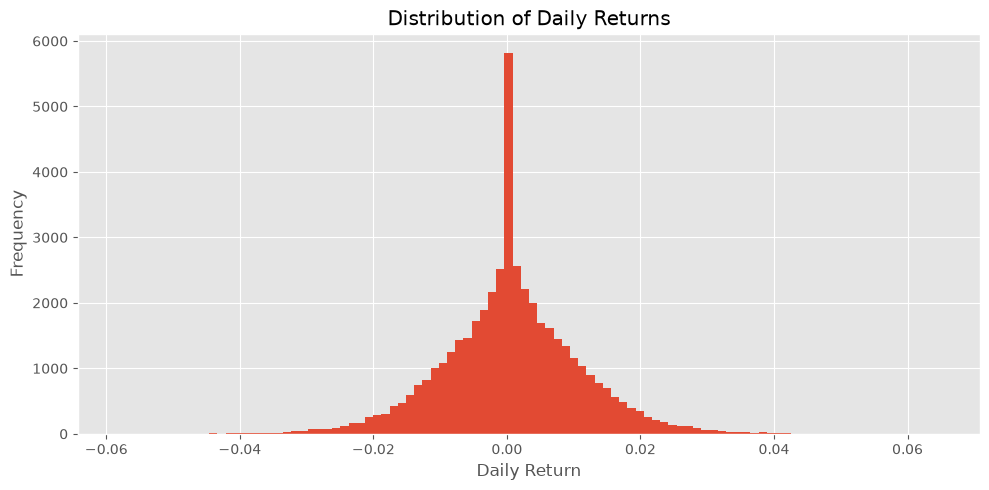

In [7]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# CAGR (Compound Annual Growth Rate)

CAGR measures the annualized growth rate of a mutual fund over a specified period. It smooths out yearly fluctuations and provides a consistent measure of long-term performance.

In [8]:
def calculate_cagr(nav_data, years):
    results = []

    for code in nav_data["amfi_code"].unique():

        fund = nav_data[nav_data["amfi_code"] == code].sort_values("date")

        if len(fund) < years * 250:
            continue

        start_nav = fund.iloc[-(years * 250)]["nav"]
        end_nav = fund.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append({
            "amfi_code": code,
            f"CAGR_{years}Y": round(cagr, 2)
        })

    return pd.DataFrame(results)

In [9]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [14]:
# Merge 1-Year and 3-Year CAGR
cagr = cagr_1.merge(cagr_3, on="amfi_code", how="outer")

# Since 5-year data is unavailable, create an empty column
cagr["CAGR_5Y"] = np.nan

# Merge with fund names
cagr = cagr.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
cagr = cagr[
    [
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

cagr.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,HDFC Top 100 Fund - Regular Plan - Growth,-3.79,-0.18,NaN
1,HDFC Short Term Debt Fund - Regular - Growth,2.18,4.81,NaN
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,46.13,33.55,NaN
3,ABSL Frontline Equity Fund - Regular - Growth,43.86,31.56,NaN
4,ABSL Small Cap Fund - Regular - Growth,-24.72,-3.10,NaN


In [11]:
print(cagr_1.head())
print(cagr_1.shape)

   amfi_code  CAGR_1Y
0     100016    -3.79
1     100025     2.18
2     100033    46.13
3     101206    43.86
4     101207   -24.72
(40, 2)


In [12]:
print(cagr_3.head())
print(cagr_3.shape)

   amfi_code  CAGR_3Y
0     100016    -0.18
1     100025     4.81
2     100033    33.55
3     101206    31.56
4     101207    -3.10
(40, 2)


In [13]:
print(cagr_5.head())
print(cagr_5.shape)

Empty DataFrame
Columns: []
Index: []
(0, 0)


In [15]:
cagr.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("✅ CAGR comparison saved successfully.")

✅ CAGR comparison saved successfully.


**Note:** The provided NAV dataset contains historical data from 2022 onwards. Therefore, true 5-year CAGR values cannot be computed and are marked as **NaN (Not Available)**.

# Sharpe Ratio Analysis

The Sharpe Ratio measures the risk-adjusted return of a mutual fund. Higher values indicate better returns for each unit of risk taken.

In [16]:
# Risk-free rate
risk_free_rate = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252
    annual_std = returns.std() * np.sqrt(252)

    sharpe = (annual_return - risk_free_rate) / annual_std

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [17]:
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df = sharpe_df[
    [
        "scheme_name",
        "Sharpe_Ratio"
    ]
]

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df.head(10)

,scheme_name,Sharpe_Ratio,Rank
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448,1
30,Kotak Flexicap Fund - Regular - Growth,1.307,2
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.235,3
19,SBI Bluechip Fund - Regular Plan - Growth,1.208,4
25,ICICI Pru Midcap Fund - Regular - Growth,1.180,5
38,DSP Midcap Fund - Regular - Growth,1.132,6
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094,7
9,Nippon India Large Cap Fund - Regular - Growth,1.082,8
3,ABSL Frontline Equity Fund - Regular - Growth,1.027,9
24,ICICI Pru Bluechip Fund - Direct - Growth,1.027,10


In [18]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio_rankings.csv",
    index=False
)

print("✅ Sharpe Ratio rankings saved successfully.")

✅ Sharpe Ratio rankings saved successfully.


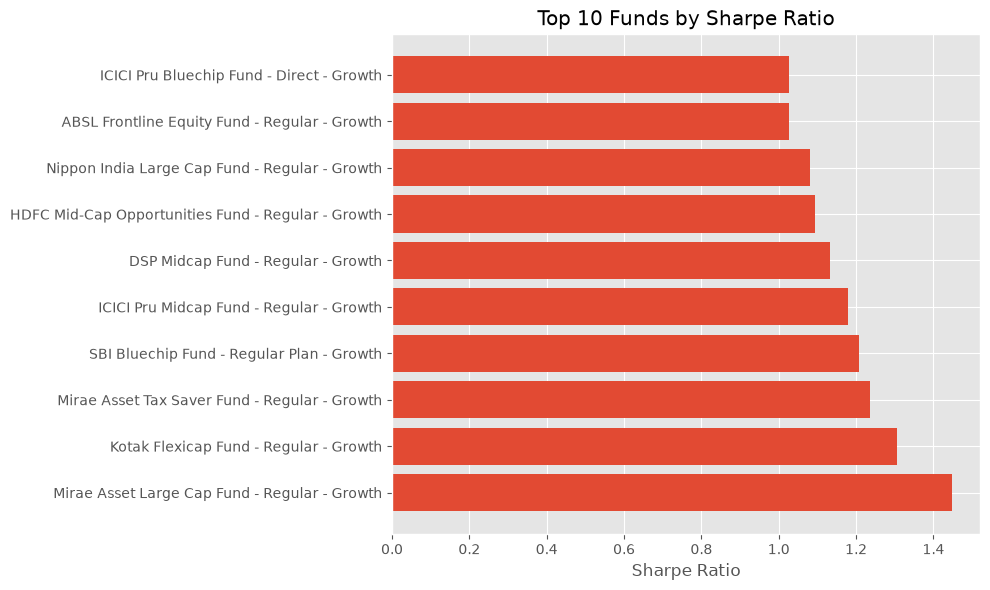

In [19]:
plt.figure(figsize=(10,6))

top10 = sharpe_df.head(10)

plt.barh(
    top10["scheme_name"],
    top10["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sortino Ratio Analysis

The Sortino Ratio evaluates the risk-adjusted return of a mutual fund by considering only downside volatility. It provides a better measure of performance when investors are primarily concerned about negative returns.

In [20]:
# Risk-free rate
risk_free_rate = 0.065

sortino_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252

    # Only negative returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std() * np.sqrt(252)

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": round(sortino, 3)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [21]:
sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df = sortino_df[
    [
        "scheme_name",
        "Sortino_Ratio"
    ]
]

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False,
    na_position="last"
)

sortino_df["Rank"] = range(1, len(sortino_df) + 1)

sortino_df.head(10)

,scheme_name,Sortino_Ratio,Rank
34,Mirae Asset Large Cap Fund - Regular - Growth,2.386,1
30,Kotak Flexicap Fund - Regular - Growth,2.364,2
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.147,3
19,SBI Bluechip Fund - Regular Plan - Growth,2.140,4
25,ICICI Pru Midcap Fund - Regular - Growth,2.029,5
38,DSP Midcap Fund - Regular - Growth,1.875,6
9,Nippon India Large Cap Fund - Regular - Growth,1.850,7
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829,8
24,ICICI Pru Bluechip Fund - Direct - Growth,1.805,9
3,ABSL Frontline Equity Fund - Regular - Growth,1.800,10


In [22]:
sortino_df.to_csv(
    "../reports/sortino_ratio_rankings.csv",
    index=False
)

print("✅ Sortino Ratio rankings saved successfully.")

✅ Sortino Ratio rankings saved successfully.


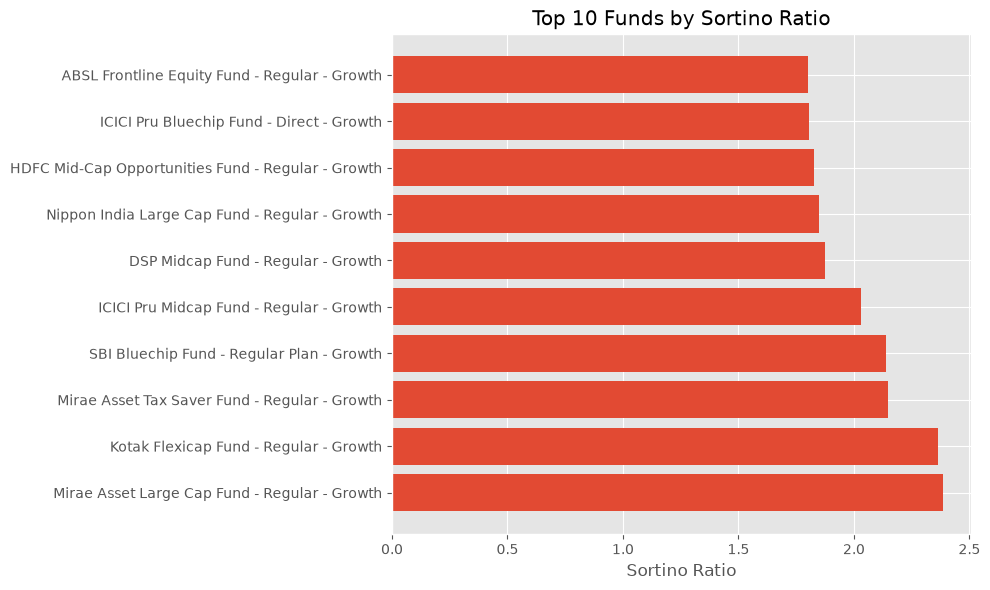

In [23]:
plt.figure(figsize=(10,6))

top10 = sortino_df.head(10)

plt.barh(
    top10["scheme_name"],
    top10["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Benchmark Index Data Exploration

This section explores the benchmark index dataset that will be used for Alpha and Beta calculations.

In [24]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.head())

print("\nColumns:")
print(benchmark.columns)

print("\nData Types:")
print(benchmark.dtypes)

print("\nShape:")
print(benchmark.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns:
Index(['date', 'index_name', 'close_value'], dtype='str')

Data Types:
date               str
index_name         str
close_value    float64
dtype: object

Shape:
(8050, 3)


# Benchmark Daily Returns

Prepare NIFTY100 daily returns for Alpha and Beta calculation.

In [25]:
# Convert date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Daily returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


# Alpha and Beta Calculation

Alpha and Beta are computed using linear regression between fund daily returns and NIFTY100 daily returns.

In [31]:
alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": code,
        "Alpha": round(intercept * 252, 4),
        "Beta": round(slope, 4),
        "R_Squared": round(r_value**2, 4)
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.0375,-0.0583,0.0027
1,100025,0.0428,0.0012,0.0000
2,100033,0.2720,0.0051,0.0000
3,101206,0.2140,0.0211,0.0003
4,101207,0.1090,-0.0653,0.0011


In [32]:
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta = alpha_beta[
    [
        "scheme_name",
        "Alpha",
        "Beta",
        "R_Squared"
    ]
]

alpha_beta.head(10)

,scheme_name,Alpha,Beta,R_Squared
0,HDFC Top 100 Fund - Regular Plan - Growth,0.0375,-0.0583,0.0027
1,HDFC Short Term Debt Fund - Regular - Growth,0.0428,0.0012,0.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2720,0.0051,0.0000
3,ABSL Frontline Equity Fund - Regular - Growth,0.2140,0.0211,0.0003
4,ABSL Small Cap Fund - Regular - Growth,0.1090,-0.0653,0.0011
5,ABSL Liquid Fund - Regular - Growth,0.0609,0.0003,0.0000
6,UTI Nifty 50 Index Fund - Regular - Growth,0.1705,-0.0195,0.0004
7,UTI Mid Cap Fund - Regular - Growth,0.0290,-0.0421,0.0009
8,UTI Flexi Cap Fund - Regular - Growth,0.1621,0.0167,0.0002
9,Nippon India Large Cap Fund - Regular - Growth,0.2183,-0.0084,0.0001


In [33]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("✅ alpha_beta.csv saved successfully.")

✅ alpha_beta.csv saved successfully.


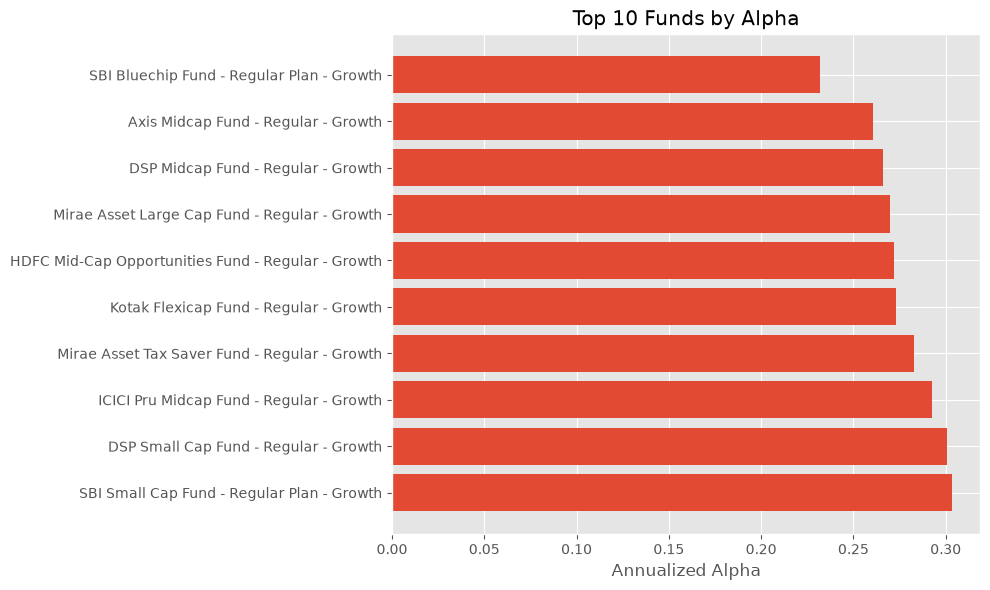

In [34]:
top10_alpha = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_alpha["scheme_name"],
    top10_alpha["Alpha"]
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Annualized Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [28]:
print(nifty100.shape)
print(nifty100.head())

(1150, 4)
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [29]:
fund = nav[nav["amfi_code"] == nav["amfi_code"].unique()[0]][["date", "daily_return"]]

merged = pd.merge(
    fund,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
).dropna()

print(merged.shape)
print(merged.head())

(1149, 3)
        date  daily_return  benchmark_return
1 2022-01-04     -0.010306         -0.013540
2 2022-01-05      0.012865          0.004003
3 2022-01-06     -0.011377         -0.002935
4 2022-01-07     -0.001210          0.006150
5 2022-01-10     -0.008639         -0.008351


In [35]:
print(len(alpha_beta_results))

40


In [36]:
print(alpha_beta.head())
print(alpha_beta.shape)

                                         scheme_name   Alpha    Beta  \
0          HDFC Top 100 Fund - Regular Plan - Growth  0.0375 -0.0583   
1       HDFC Short Term Debt Fund - Regular - Growth  0.0428  0.0012   
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.2720  0.0051   
3      ABSL Frontline Equity Fund - Regular - Growth  0.2140  0.0211   
4             ABSL Small Cap Fund - Regular - Growth  0.1090 -0.0653   

   R_Squared  
0     0.0027  
1     0.0000  
2     0.0000  
3     0.0003  
4     0.0011  
(40, 4)


# Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest percentage decline from a fund's historical peak NAV. It helps assess downside risk.

In [37]:
mdd_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].sort_values("date").copy()

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (fund["nav"] / fund["running_max"]) - 1

    # Worst drawdown
    min_index = fund["drawdown"].idxmin()

    worst_row = fund.loc[min_index]

    mdd_results.append({
        "amfi_code": code,
        "Maximum_Drawdown": round(worst_row["drawdown"] * 100, 2),
        "Worst_Date": worst_row["date"]
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-24.73,2022-09-15
1,100025,-4.31,2023-07-28
2,100033,-16.22,2022-05-12
3,101206,-11.29,2023-07-05
4,101207,-35.45,2026-05-11


In [38]:
mdd_df = mdd_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

mdd_df = mdd_df[
    [
        "scheme_name",
        "Maximum_Drawdown",
        "Worst_Date"
    ]
]

mdd_df.head()

,scheme_name,Maximum_Drawdown,Worst_Date
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-09-15
1,HDFC Short Term Debt Fund - Regular - Growth,-4.31,2023-07-28
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.22,2022-05-12
3,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05
4,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11


In [39]:
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("✅ Maximum Drawdown saved successfully.")

✅ Maximum Drawdown saved successfully.


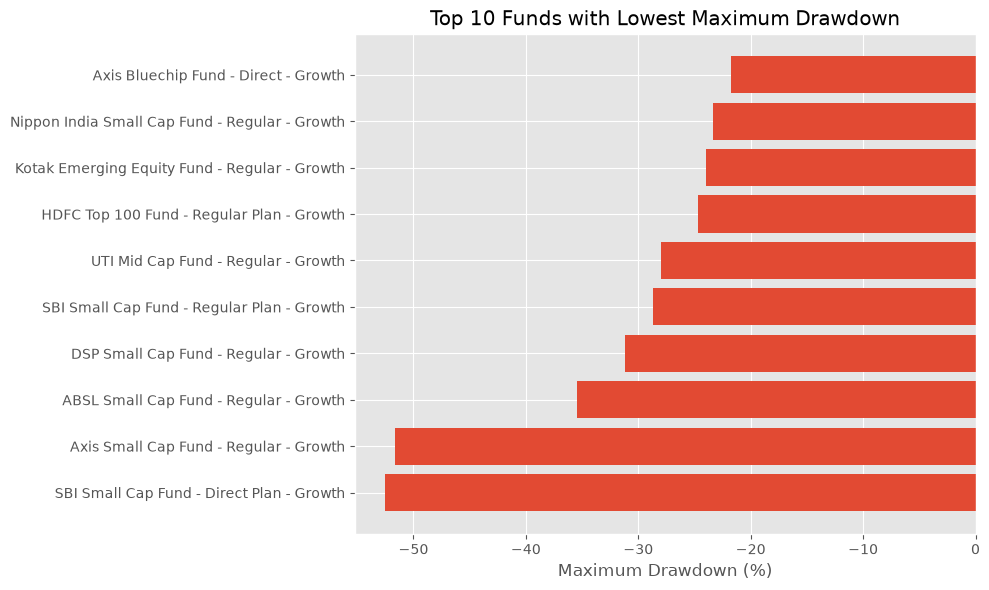

In [40]:
top10_dd = mdd_df.sort_values(
    "Maximum_Drawdown"
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_dd["scheme_name"],
    top10_dd["Maximum_Drawdown"]
)

plt.title("Top 10 Funds with Lowest Maximum Drawdown")
plt.xlabel("Maximum Drawdown (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Fund Scorecard (0–100)

The Fund Scorecard combines multiple performance metrics into a single composite score, making it easier to compare mutual funds.

In [41]:
# Copy required data
scorecard = cagr.copy()

# Merge Sharpe
scorecard = scorecard.merge(
    sharpe_df[["scheme_name", "Sharpe_Ratio"]],
    on="scheme_name"
)

# Merge Alpha
scorecard = scorecard.merge(
    alpha_beta[["scheme_name", "Alpha"]],
    on="scheme_name"
)

# Merge Expense Ratio
scorecard = scorecard.merge(
    performance[["scheme_name", "expense_ratio_pct"]],
    on="scheme_name"
)

# Merge Maximum Drawdown
scorecard = scorecard.merge(
    mdd_df[["scheme_name", "Maximum_Drawdown"]],
    on="scheme_name"
)

scorecard.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,expense_ratio_pct,Maximum_Drawdown
0,HDFC Top 100 Fund - Regular Plan - Growth,-3.79,-0.18,NaN,-0.202,0.0375,1.55,-24.73
1,HDFC Short Term Debt Fund - Regular - Growth,2.18,4.81,NaN,-0.567,0.0428,0.56,-4.31
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,46.13,33.55,NaN,1.094,0.2720,1.38,-16.22
3,ABSL Frontline Equity Fund - Regular - Growth,43.86,31.56,NaN,1.027,0.2140,1.60,-11.29
4,ABSL Small Cap Fund - Regular - Growth,-24.72,-3.10,NaN,0.163,0.1090,1.53,-35.45


In [42]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

In [43]:
scorecard["Fund_Score"] = (

    0.30 * scorecard["Return_Rank"]

    + 0.25 * scorecard["Sharpe_Rank"]

    + 0.20 * scorecard["Alpha_Rank"]

    + 0.15 * scorecard["Expense_Rank"]

    + 0.10 * scorecard["Drawdown_Rank"]

)

# Convert to 0–100 scale
scorecard["Fund_Score"] = (

    100 *

    (scorecard["Fund_Score"].max() - scorecard["Fund_Score"])

    /

    (

        scorecard["Fund_Score"].max()

        - scorecard["Fund_Score"].min()

    )

).round(2)

In [44]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,expense_ratio_pct,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
34,Mirae Asset Large Cap Fund - Regular - Growth,14.58,33.04,NaN,1.448,0.2698,1.46,-11.27,3.0,1.0,7.0,23.0,8.0,100.00
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,46.13,33.55,NaN,1.094,0.2720,1.38,-16.22,2.0,7.0,6.0,17.0,20.0,95.52
25,ICICI Pru Midcap Fund - Regular - Growth,33.02,31.08,NaN,1.180,0.2926,1.36,-18.19,5.0,5.0,3.0,15.0,25.0,95.52
30,Kotak Flexicap Fund - Regular - Growth,29.46,26.24,NaN,1.307,0.2733,1.45,-12.97,10.0,2.0,5.0,22.0,13.0,92.08
16,Axis Midcap Fund - Regular - Growth,29.19,35.21,NaN,0.998,0.2608,1.38,-20.96,1.0,11.0,9.0,17.0,28.0,88.30
24,ICICI Pru Bluechip Fund - Direct - Growth,9.87,27.13,NaN,1.027,0.2119,0.80,-12.59,8.0,9.5,13.0,12.0,12.0,87.69
19,SBI Bluechip Fund - Regular Plan - Growth,49.32,28.08,NaN,1.208,0.2320,1.54,-15.01,6.0,4.0,10.0,30.5,17.0,85.28
3,ABSL Frontline Equity Fund - Regular - Growth,43.86,31.56,NaN,1.027,0.2140,1.60,-11.29,4.0,9.5,12.0,36.5,9.0,80.90
36,Mirae Asset Tax Saver Fund - Regular - Growth,45.75,22.98,NaN,1.235,0.2827,1.60,-16.40,13.0,3.0,4.0,36.5,21.0,78.57
21,SBI Small Cap Fund - Regular Plan - Growth,82.41,25.24,NaN,0.945,0.3034,1.43,-28.71,11.0,14.0,1.0,21.0,36.0,76.08


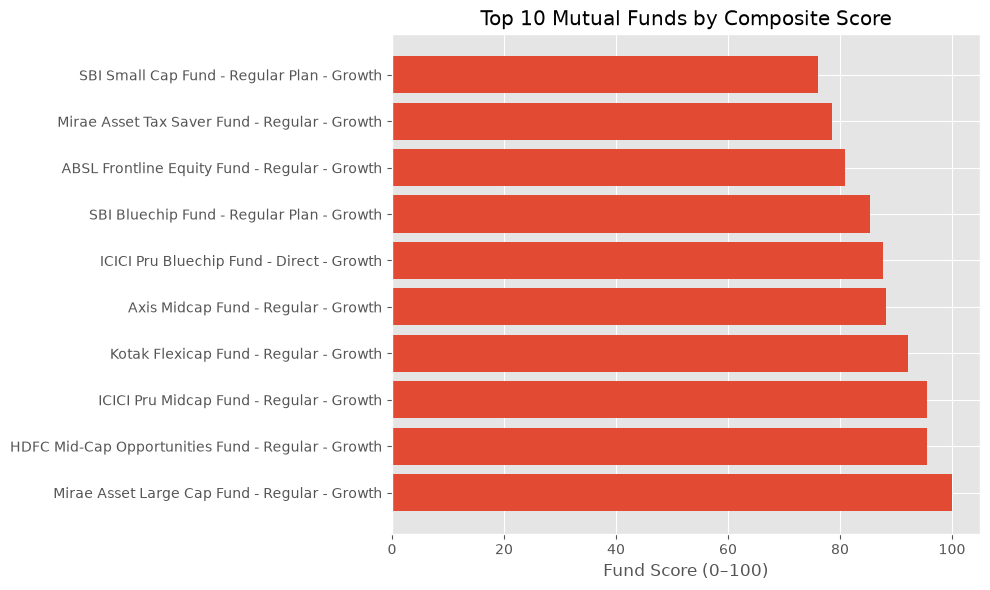

In [45]:
top10 = scorecard.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score (0–100)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Benchmark Comparison

This section compares the Top 5 mutual funds with the NIFTY50 and NIFTY100 benchmark indices and computes the tracking error.

In [46]:
top5_funds = scorecard.head(5)["scheme_name"]

top5_codes = fund_master[
    fund_master["scheme_name"].isin(top5_funds)
]["amfi_code"]

top5_codes

7     100033
12    120505
22    120843
26    119094
34    148567
Name: amfi_code, dtype: int64

In [47]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark_plot = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

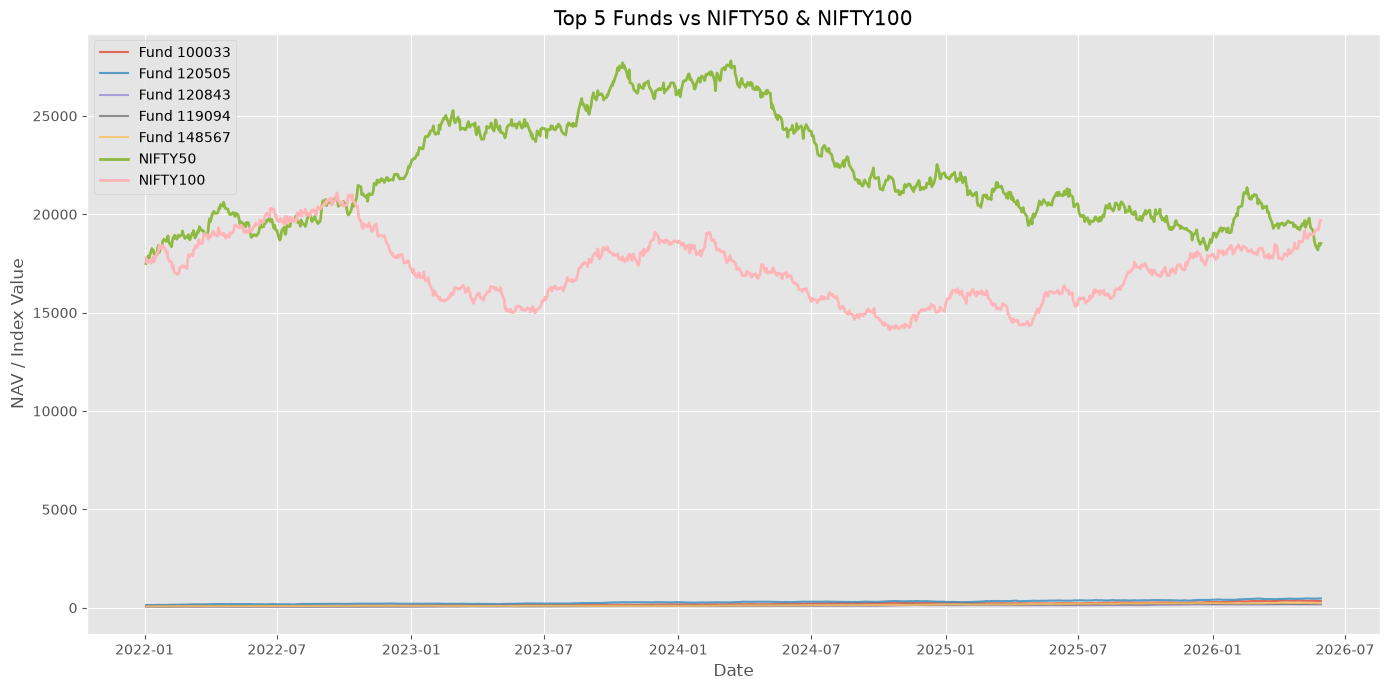

In [48]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for code in top5_codes:

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        alpha=0.8,
        label=f"Fund {code}"
    )

# Plot Benchmarks
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=2,
        label=index
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
tracking_results = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": code,
        "Tracking_Error": round(tracking_error,4)
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df = tracking_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

tracking_df

,amfi_code,Tracking_Error,scheme_name
0,100033,0.2287,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,120505,0.2320,ICICI Pru Midcap Fund - Regular - Growth
2,120843,0.2064,Kotak Flexicap Fund - Regular - Growth
3,119094,0.2377,Axis Midcap Fund - Regular - Growth
4,148567,0.1897,Mirae Asset Large Cap Fund - Regular - Growth


In [50]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("✅ tracking_error.csv saved successfully.")

✅ tracking_error.csv saved successfully.
